In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the Data
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/sample_Superstore.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
df.shape

(10194, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [ ]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby('Category')['Sales'].sum(), df.groupby('Category')['Profit'].sum()

(Category
 Furniture          754747.7613
 Office Supplies    731893.3140
 Technology         839893.2790
 Name: Sales, dtype: float64,
 Category
 Furniture           19729.9956
 Office Supplies    126023.4434
 Technology         146543.3756
 Name: Profit, dtype: float64)

In [ ]:
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Sub-Category,
Copiers,56093.9365
Phones,45050.8265
Accessories,41936.6357
Paper,34511.5070
Binders,31426.1003
Chairs,27223.5323
Storage,21285.1115
Appliances,18329.4844
Furnishings,13891.7430


In [ ]:
df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

,Discount
Sub-Category,
Binders,0.369057
Machines,0.304274
Tables,0.258129
Bookcases,0.215259
Chairs,0.169243
Appliances,0.164557
Copiers,0.157143
Phones,0.152602
Furnishings,0.138057


In [ ]:
df[df['Sub-Category']=='Binders']['Profit'].sum()

np.float64(31426.100299999984)

In [ ]:
df.groupby('Sub-Category').agg({'Discount':'mean', 'Profit':'sum'}).sort_values('Profit')

,Discount,Profit
Sub-Category,,
Tables,0.258129,-17753.2061
Bookcases,0.215259,-3632.0736
Supplies,0.076042,-1171.3945
Fasteners,0.078603,2428.6358
Machines,0.304274,3461.9769
Labels,0.070924,5572.7780
Art,0.075030,6653.1962
Envelopes,0.079688,6988.0247
Furnishings,0.138057,13891.7430


In [ ]:
print(df[df['Sub-Category']=='Tables']['Quantity'].sum())
print(df[df['Sub-Category']=='Binders']['Quantity'].sum())

1261
6071


In [ ]:
df[['Sales','Profit']].corr()

,Sales,Profit
Sales,1.00000,0.48146
Profit,0.48146,1.00000


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

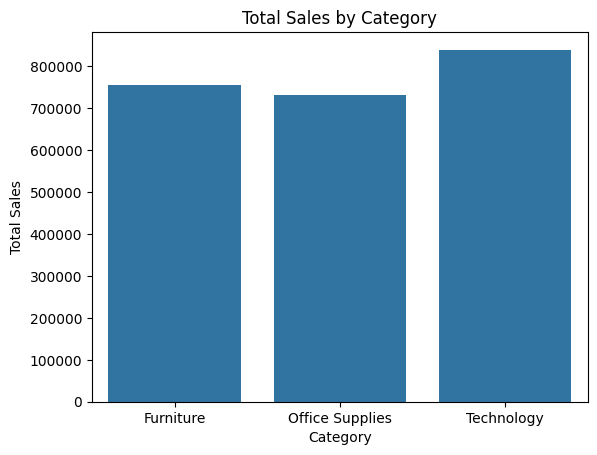

In [ ]:
sns.barplot(x='Category', y='Sales', data=category_sales)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

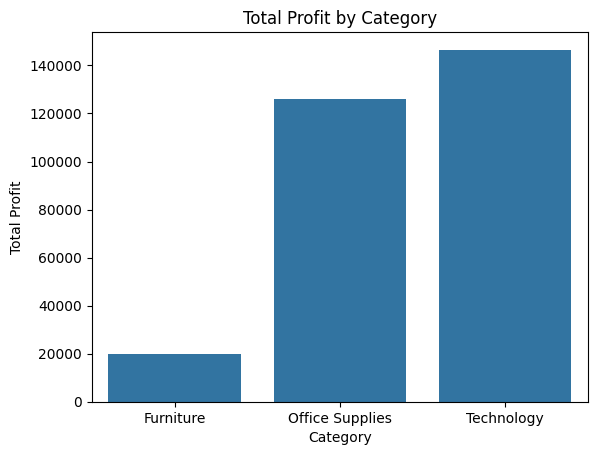

In [ ]:
sns.barplot(x='Category', y='Profit', data=category_profit)
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

<Axes: xlabel='Sales', ylabel='Profit'>

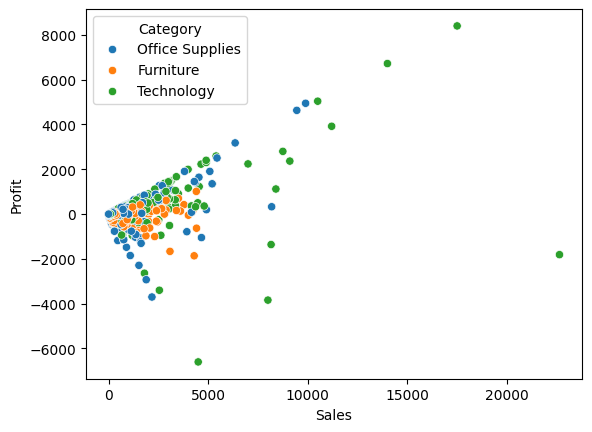

In [ ]:
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category')

In [ ]:
sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()

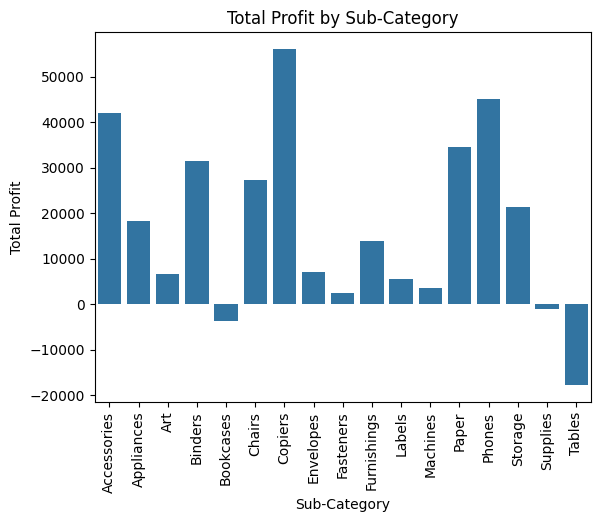

In [ ]:
sns.barplot(x='Sub-Category', y='Profit', data=sub_category_profit)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=90)
plt.show()

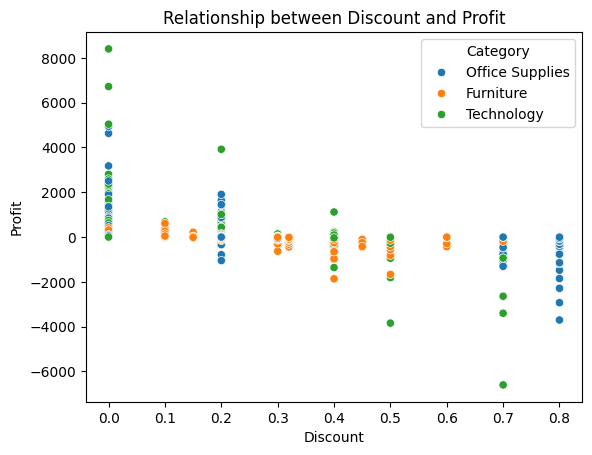

In [ ]:
sns.scatterplot(x='Discount', y='Profit', data=df, hue='Category')
plt.title('Relationship between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

In [ ]:
regional_profit=df.groupby('Region')['Profit'].sum().reset_index()


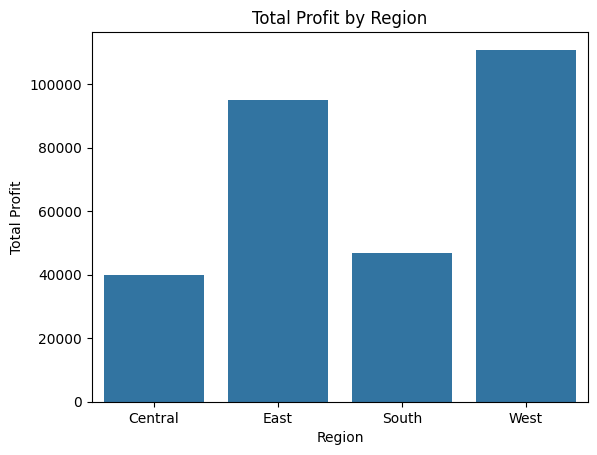

In [ ]:
sns.barplot(x='Region', y='Profit', data=regional_profit)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

In [ ]:
regional_sales=df.groupby('Region')['Sales'].sum().reset_index()

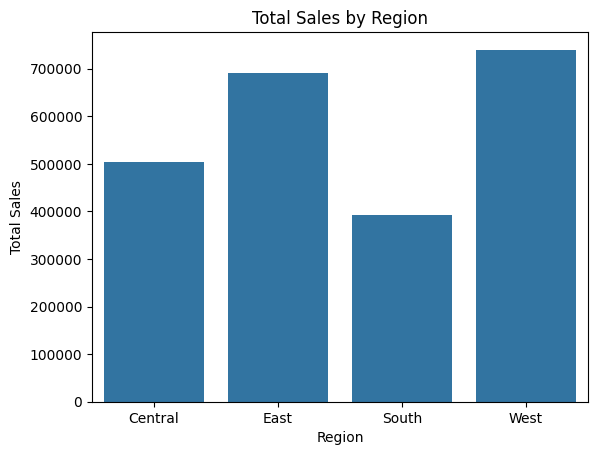

In [ ]:
sns.barplot(x='Region', y='Sales', data=regional_sales)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
df[df['Region']=='Central'].groupby('Region')['Discount'].mean()

,Discount
Region,
Central,0.241002


In [ ]:
regional_discount=df.groupby('Region')['Discount'].mean().sort_values(ascending=False).reset_index()
regional_discount

,Region,Discount
0,Central,0.241002
1,South,0.147253
2,East,0.143436
3,West,0.108946


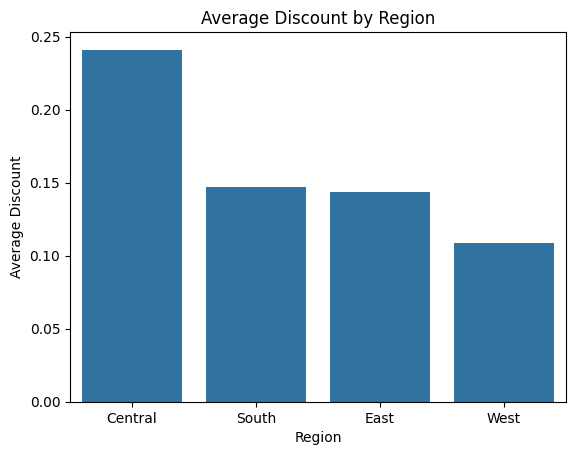

In [ ]:
sns.barplot(x='Region',y='Discount',data=regional_discount)
plt.title('Average Discount by Region')
plt.xlabel('Region')
plt.ylabel('Average Discount')
plt.show()

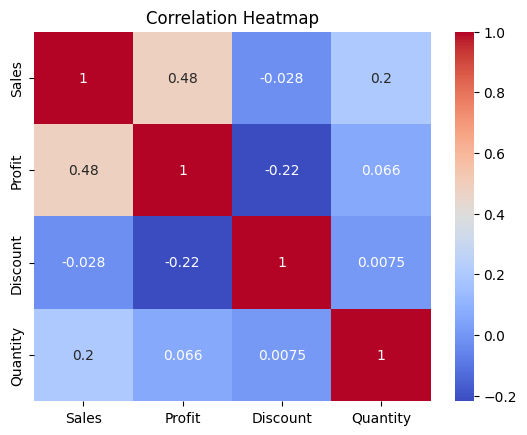

In [ ]:
sns.heatmap(df[['Sales','Profit','Discount','Quantity']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()